# Market Capitalization & Stock Price Change Analysis

This notebook analyzes the relationship between company Market Capitalization and stock price changes using Yahoo Finance data.
The goal is to help investors and management understand whether large companies always show positive price performance.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Symbol      1250 non-null   object 
 1   Name        1250 non-null   object 
 2   Price       1250 non-null   object 
 3   Change      1250 non-null   float64
 4   Market Cap  1250 non-null   object 
 5   Pe Ratio    1235 non-null   float64
dtypes: float64(2), object(4)
memory usage: 58.7+ KB


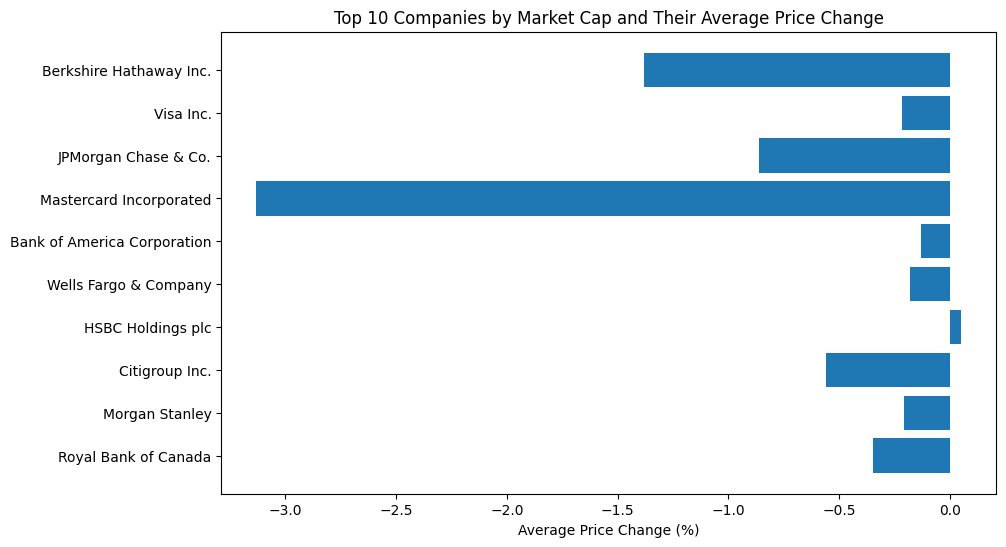

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data/data yahoo.csv")
df.head()

df.info()
df.describe()   

df['Market Cap'] = (
    df['Market Cap']
    .str.replace('B', '', regex=False)
    .astype(float)
)

df = df.drop_duplicates()

summary = (
    df.groupby('Name')
    .agg(
        marketcap=('Market Cap', 'max'),
        mean_change=('Change', 'mean')
    )
)
summary.head()

top10 = summary.sort_values(
    by='marketcap',
    ascending=False
).head(10)

top10

plt.figure(figsize=(10,6))
plt.barh(
    top10.index,
    top10['mean_change']
)
plt.xlabel('Average Price Change (%)')
plt.title('Top 10 Companies by Market Cap and Their Average Price Change')
plt.gca().invert_yaxis()

plt.savefig("images/top10_marketcap_change.png", bbox_inches="tight")
plt.show()


## Insight

The analysis shows that several companies with large market capitalization have low or even negative average price changes.
This indicates that company size alone does not guarantee positive stock performance in the short term.


## Conclusion

Market Capitalization should not be used as the only indicator for investment decisions.
Combining Market Cap with price movement analysis provides a more balanced perspective for both investors and management.
